In [1]:
import torch as th
import torch.nn.functional as F
import numpy as np
import timeit 
from matplotlib import cm
import matplotlib.pyplot as plt

In [2]:
X = th.linspace(-6, 6, 100) 
Y = th.linspace(-6, 6, 100)
x1, x2 = np.meshgrid(X.numpy(),Y.numpy())



X_plot = th.stack([th.tensor(x1.flatten()), th.tensor(x2.flatten())]).T


In [97]:
V_load_pen = np.load('export/invpen_lyapunov_function.npy')
V_load_pen_common = np.load('export/common_lyapunov_function.npy')
V_load_lin = np.load('export/lin2_lyapunov_function.npy')

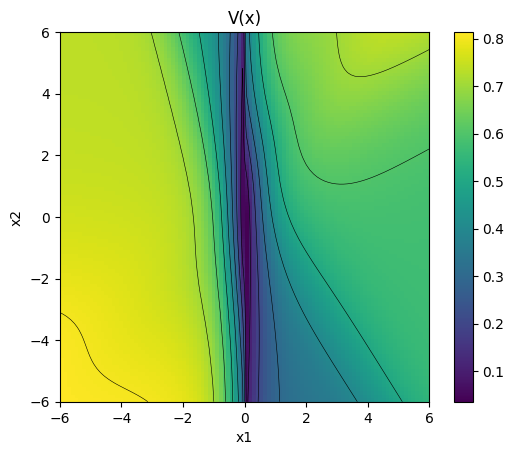

In [57]:
plt.imshow(V_load_pen, extent=[-6, 6, -6, 6], origin='lower')
plt.colorbar(cmap=cm.coolwarm)
plt.title('V(x)')
plt.xlabel('x1')
plt.ylabel('x2')
# plt.xticks(ticks=range(100), labels=X)
plt.contour(x1,x2,V_load_pen,8,linewidths=0.4, colors='k')
plt.show()

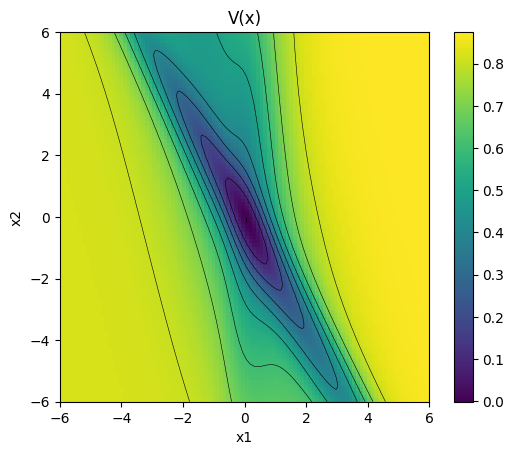

In [62]:
plt.imshow(V_load_pen_common, extent=[-6, 6, -6, 6], origin='lower')
plt.colorbar(cmap=cm.coolwarm)
plt.title('V(x)')
plt.xlabel('x1')
plt.ylabel('x2')
# plt.xticks(ticks=range(100), labels=X)
plt.contour(x1,x2,V_load_pen_common,8,linewidths=0.4, colors='k')
plt.show()

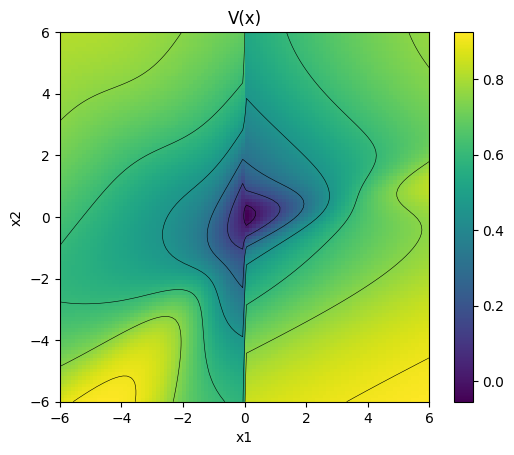

In [98]:
plt.imshow(V_load_lin, extent=[-6, 6, -6, 6], origin='lower')
plt.colorbar(cmap=cm.coolwarm)
plt.title('V(x)')
plt.xlabel('x1')
plt.ylabel('x2')
# plt.xticks(ticks=range(100), labels=X)
plt.contour(x1,x2,V_load_lin,8,linewidths=0.4, colors='k')
plt.show()

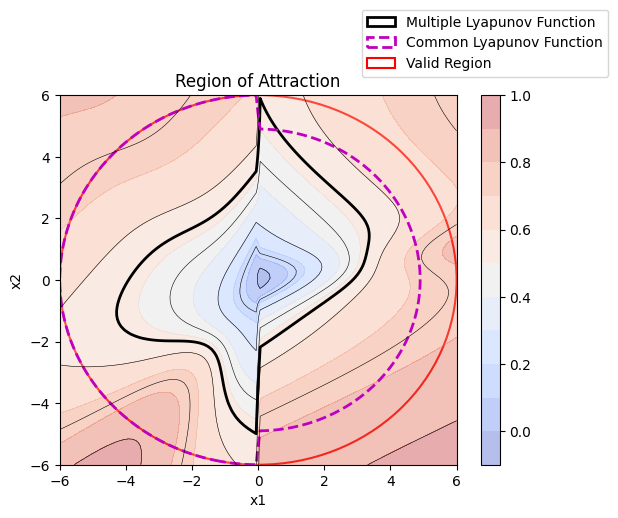

In [120]:
# plt.figure(dpi=300)
ax = plt.gca()

# Lyapunov functions
# V_SOS = x1**6*(2.11*x1**6 + 0.006847*x1**5*x2 + 0.0937*x1**4*x2**2 - 6.223e-8*x1**3*x2**3 - 1.307e-9*x1**2*x2**4 - 5.609e-9*x1**2 - 3.692e-9*x1*x2**5 - 5.893e-10*x2**6 + 2.132e-9*x2**2) + x1**5*x2*(0.006847*x1**6 + 0.0937*x1**5*x2 - 0.0271*x1**4*x2**2 - 1.307e-9*x1**3*x2**3 - 3.692e-9*x1**2*x2**4 + 2.132e-9*x1**2 - 5.893e-10*x1*x2**5 + 4.724e-10*x2**6 + 6.079e-10*x2**2) + x1**4*x2**2*(0.0937*x1**6 - 0.0271*x1**5*x2 + 0.03769*x1**4*x2**2 - 3.692e-9*x1**3*x2**3 - 5.893e-10*x1**2*x2**4 + 6.079e-10*x1**2 + 4.724e-10*x1*x2**5 + 2.836e-10*x2**6 + 1.731e-9*x2**2) + x1**3*x2**3*(-6.223e-8*x1**6 - 1.307e-9*x1**5*x2 - 3.692e-9*x1**4*x2**2 + 5.913*x1**3*x2**3 + 0.2135*x1**2*x2**4 + 2.11*x1**2 + 0.1824*x1*x2**5 + 0.009201*x2**6 + 0.006847*x2**2) + x1**2*x2**4*(-1.307e-9*x1**6 - 3.692e-9*x1**5*x2 - 5.893e-10*x1**4*x2**2 + 0.2135*x1**3*x2**3 + 0.1824*x1**2*x2**4 + 0.006847*x1**2 + 0.009201*x1*x2**5 + 0.01684*x2**6 + 0.0937*x2**2) + x1**2*(-5.609e-9*x1**6 + 2.132e-9*x1**5*x2 + 6.079e-10*x1**4*x2**2 + 2.11*x1**3*x2**3 + 0.006847*x1**2*x2**4 + 4.09*x1**2 + 0.0937*x1*x2**5 - 0.0271*x2**6 + 0.09225*x2**2) + x1*x2**5*(-3.692e-9*x1**6 - 5.893e-10*x1**5*x2 + 4.724e-10*x1**4*x2**2 + 0.1824*x1**3*x2**3 + 0.009201*x1**2*x2**4 + 0.0937*x1**2 + 0.01684*x1*x2**5 + 0.02061*x2**6 - 0.0271*x2**2) + x2**6*(-5.893e-10*x1**6 + 4.724e-10*x1**5*x2 + 2.836e-10*x1**4*x2**2 + 0.009201*x1**3*x2**3 + 0.01684*x1**2*x2**4 - 0.0271*x1**2 + 0.02061*x1*x2**5 + 0.01081*x2**6 + 0.03769*x2**2) + x2**2*(2.132e-9*x1**6 + 6.079e-10*x1**5*x2 + 1.731e-9*x1**4*x2**2 + 0.006847*x1**3*x2**3 + 0.0937*x1**2*x2**4 + 0.09225*x1**2 - 0.0271*x1*x2**5 + 0.03769*x2**6 + 0.2055*x2**2) - 17.0341495901499
V_lqr = 85.5250*x1**2 + 2*14.1518*x1*x2 + 2.4269*x2**2 #narrow
# V = tanh((0.1592191 + 0.6047373* tanh((-1.2250961 - 1.1751087 * x1 + 0.028802002 * x2)) - 0.69419956 * tanh((-0.81576663 + 0.02652748* x1 - 0.00072127824999999998 * x2)) - 1.1177092 * tanh((-0.53083205 + 0.043899357 * x1 - 0.0029811477000000002 * x2)) - 1.1329674000000001 * tanh((0.89248989999999995 - 0.55178492999999995 * x1 - 0.034781724 * x2)) + 0.77995585999999995 * tanh((0.93392560000000002 - 0.0067463684999999997 * x1 - 0.0067418180000000001 * x2)) - 0.26213419999999998 * tanh((1.0895116 + 0.44463265000000002 * x1 + 0.2598702 * x2))))-0.212

V_lqr_lin = []

for x in X_plot:
    P1 = th.eye(2) * 0.16666667
    P2 = th.eye(2) * 0.25

    if x[0] <= 0:
        V_lqr_lin.append(x@P1@x)
    
    else:
        V_lqr_lin.append(x@P2@x)

V_lqr_lin = th.tensor(V_lqr_lin).reshape(100, 100)


# Vaild Region
C = plt.Circle((0, 0),6, color='r', linewidth=1.5, fill=False)
ax.add_artist(C)

# # plot direction field
# xd = np.linspace(-6, 6, 10) 
# yd = np.linspace(-6, 6, 10)
# Xd, Yd = np.meshgrid(xd,yd)
# t = np.linspace(0,2,100)
# Plotflow(Xd, Yd, t) 

if False:
    #pendulum
    ax.contour(X,Y,V_load_pen-2.5,0,linewidths=2, colors='k', linestyles='-')
    ax.contour(X,Y,V_load_pen_common-2.38,0,linewidths=2, colors='m',linestyles='--')
    ax.contour(x1,x2,V_load_pen,8,linewidths=0.4, colors='k')
    c1 = ax.contourf(x1,x2,V_load_pen,10,alpha=0.4,cmap=cm.coolwarm)

else:
    #linear
    # ax.contour(X,Y,V_load_lin-2.25,0,linewidths=2, colors='k', linestyles='-')
    ax.contour(X,Y,V_load_lin-0.53,0,linewidths=2, colors='k', linestyles='-')
    ax.contour(X,Y,V_lqr_lin-6,0,linewidths=2, colors='m',linestyles='--')
    ax.contour(x1,x2,V_load_lin,8,linewidths=0.4, colors='k')
    c1 = ax.contourf(x1,x2,V_load_lin,10,alpha=0.4,cmap=cm.coolwarm)
plt.colorbar(c1)

plt.title('Region of Attraction')
plt.legend([plt.Rectangle((0,0),1,2,color='k',fill=False,linewidth = 2),plt.Rectangle((0,0),1,2,color='m',fill=False,linewidth = 2, linestyle='--'), C] ,['Multiple Lyapunov Function','Common Lyapunov Function','Valid Region'],
           loc='upper right', bbox_to_anchor=(1.4, 1.25))
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [99]:
from scipy.linalg import solve_continuous_lyapunov
import numpy as np

A = np.eye(2) * -3  # Your system matrix
Q = np.eye(A.shape[0])        # Choose Q > 0 (identity is fine)

P = solve_continuous_lyapunov(A.T, -Q)
print("P =\n", P)

P =
 [[0.16666667 0.        ]
 [0.         0.16666667]]


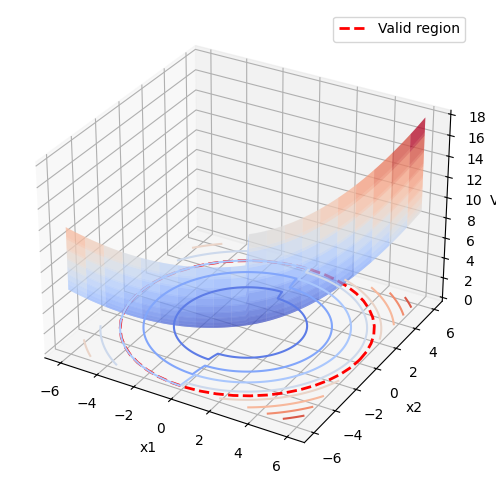

In [122]:
fig = plt.figure(figsize=(6, 6))
plt.tight_layout()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X,Y,V_lqr_lin, rstride=5, cstride=5, alpha=0.5, cmap=cm.coolwarm)
ax.contour(X,Y,V_lqr_lin,10, zdir='z', offset=0, cmap=cm.coolwarm)

# Plot Valid region computed by dReal
r=6
theta = np.linspace(0,2*np.pi,50)
xc = r*np.cos(theta)
yc = r*np.sin(theta)
ax.plot(xc[:],yc[:],'r',linestyle='--', linewidth=2 ,label='Valid region')
plt.legend(loc='upper right')
plt.xlabel('x1')
plt.ylabel('x2')
ax.set_zlabel('V(.)')
# fig.subplots_adjust(left=0.1, right=150, bottom=0.1, top=1)
plt.savefig("export/lin_common_lyapunov_function.png", dpi=300, bbox_inches='tight')
plt.show()


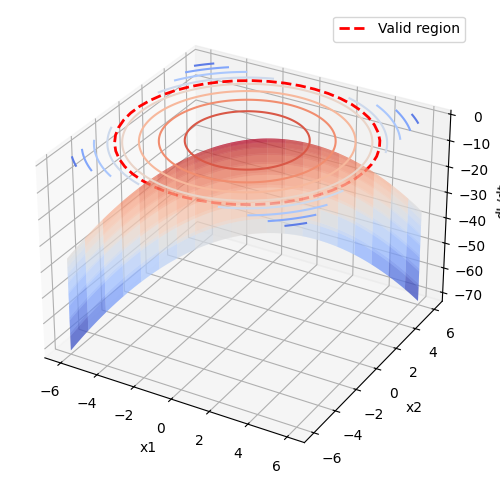

In [123]:
L_plot = []

for x in X_plot:
    P1 = th.eye(2) * 0.16666667
    P2 = th.eye(2) * 0.25

    A1 = th.eye(2)*-3
    A2 = th.eye(2)*-2

    if x[0] <= 0:
        L_plot.append(x@(A1.T@P1 + P1@A1)@x)
    
    else:
        L_plot.append(x@(A2.T@P2 + P2@A2)@x)

L_plot = th.tensor(L_plot).reshape(100, 100)



fig = plt.figure(figsize=(6, 6))
plt.tight_layout()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X,Y,L_plot, rstride=5, cstride=5, alpha=0.5, cmap=cm.coolwarm)
ax.contour(X,Y,L_plot,10, zdir='z', offset=0, cmap=cm.coolwarm)

# Plot Valid region computed by dReal
r=6
theta = np.linspace(0,2*np.pi,50)
xc = r*np.cos(theta)
yc = r*np.sin(theta)
ax.plot(xc[:],yc[:],'r',linestyle='--', linewidth=2 ,label='Valid region')
plt.legend(loc='upper right')
plt.xlabel('x1')
plt.ylabel('x2')
ax.set_zlabel('dL/dt')
# fig.subplots_adjust(left=0.1, right=150, bottom=0.1, top=1)
plt.savefig("export/lin_common_lie_derivative.png", dpi=300, bbox_inches='tight')
plt.show()